In [2]:
#File: final_project.ipynb
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd

In [3]:
df = pd.read_csv('asu.tsv', sep=';', comment='#', na_values=['', ' ', '      '])
print(df.head())
df = df.iloc[2:]

df_cleaned = df.dropna(subset = ['sma', 'mu36corr'])
df_cleaned = df_cleaned.reset_index(drop=True)

df_cleaned.head()        #By default the data has many galaxies as specified by the name column so I have to go through and clean the data

         Name     sma     ell        muFUV cumuFUV        muNUV cumuNUV  \
0         NaN  arcsec     NaN  mag/arcsec2     mag  mag/arcsec2     mag   
1  ----------     ---  ------       ------  ------       ------  ------   
2  ESO013-016       6   0.333       22.847  18.147       22.851  18.005   
3  ESO013-016      12   0.333       23.764  16.856       23.370  16.662   
4  ESO013-016      18   0.333       24.074  16.431       23.786  16.146   

            FN sma36     mu36corr tmagcorr asmag36  
0  mag/arcsec2   pix  mag/arcsec2      mag     mag  
1       ------   ---       ------   ------  ------  
2       -0.005     8       21.019   15.957  13.132  
3        0.394    16       21.606   14.891  13.132  
4        0.288    24       21.958   14.399  13.132  


,Name,sma,ell,muFUV,cumuFUV,muNUV,cumuNUV,FN,sma36,mu36corr,tmagcorr,asmag36
0,ESO013-016,6,0.333,22.847,18.147,22.851,18.005,-0.005,8,21.019,15.957,13.132
1,ESO013-016,12,0.333,23.764,16.856,23.370,16.662,0.394,16,21.606,14.891,13.132
2,ESO013-016,18,0.333,24.074,16.431,23.786,16.146,0.288,24,21.958,14.399,13.132
3,ESO013-016,24,0.333,24.049,15.965,23.777,15.712,0.272,32,22.177,14.006,13.132
4,ESO013-016,30,0.333,24.338,15.589,24.038,15.329,0.300,40,22.552,13.721,13.132


In [22]:
# Defining the main functions I will be using in this project
def mu_fit(r, mue, re, n):
    """
    This function defines the intensity, in magnitudes, of a galaxy as a function of the radius

    Parameters
    r - distance from center
    mue - half light intesity , which is the intesnity which captures half the light of the galaxy, measured in magnitudes
    re - radius at hwich half the light is captured
    n - sersic index, determines type of galaxy
    bn - coefficient to better define the model
    """
    bn = 2 * n - 0.324
    mu = mue + 2.5 * bn / (np.log(10)) * ((r / re)**(1 / n) - 1)
    return mu

def seperate(df):
    """
    This function will take in the data frame above and then output a list of arrays which are each galaxies data. 

    Parameters
    df - Dataframe to be seperated into list
    """
    final_list = [] # This will be the final list wiht all the data that I need for this project
    galaxy_name = df.iloc[1,0] # This just sets the galaxy anme to the first galaxy in the dataframe
    short_list = [] # This is an intermediate list to save each galaxies information together
    
    for i in range(len(df['Name'])):
        if df.iloc[i,0] == galaxy_name: # This checks whether the current row is the same as the current name and then if it is adds it to a list that is then appended to another list
            desired = [galaxy_name, df.iloc[i, 1], df.iloc[i,9]]
            short_list.append(desired)
        
        elif df.iloc[i, 0] != galaxy_name: # This is for when the name sarent the same in which case it appends the short list to the final and resets the short_list
            final_list.append(short_list)
            galaxy_name = df.iloc[i, 0]
            short_list = []
        if len(final_list) == 15:
            return final_list
        elif len(final_list) < 15: #ensures there is a reasonable amount of galaxies so scipy doesnt get an overflow error, 15 found experimentally
            continue
        else:
            break

def chi_squared(experimental, expected, fit_params):
    """
    This function returens the reduced chi suqred value for a data set, I dont have the error for my data so wasnt sure what to do just didnt include the error for now
    
    Parameters
    experimental - meassured values of data
    expected - theoretical values based on fit
    fit_params - number of fitted parameters
    """
    Residuals = experimental - expected
    chi = np.sum(Residuals**2)
    return chi/fit_params

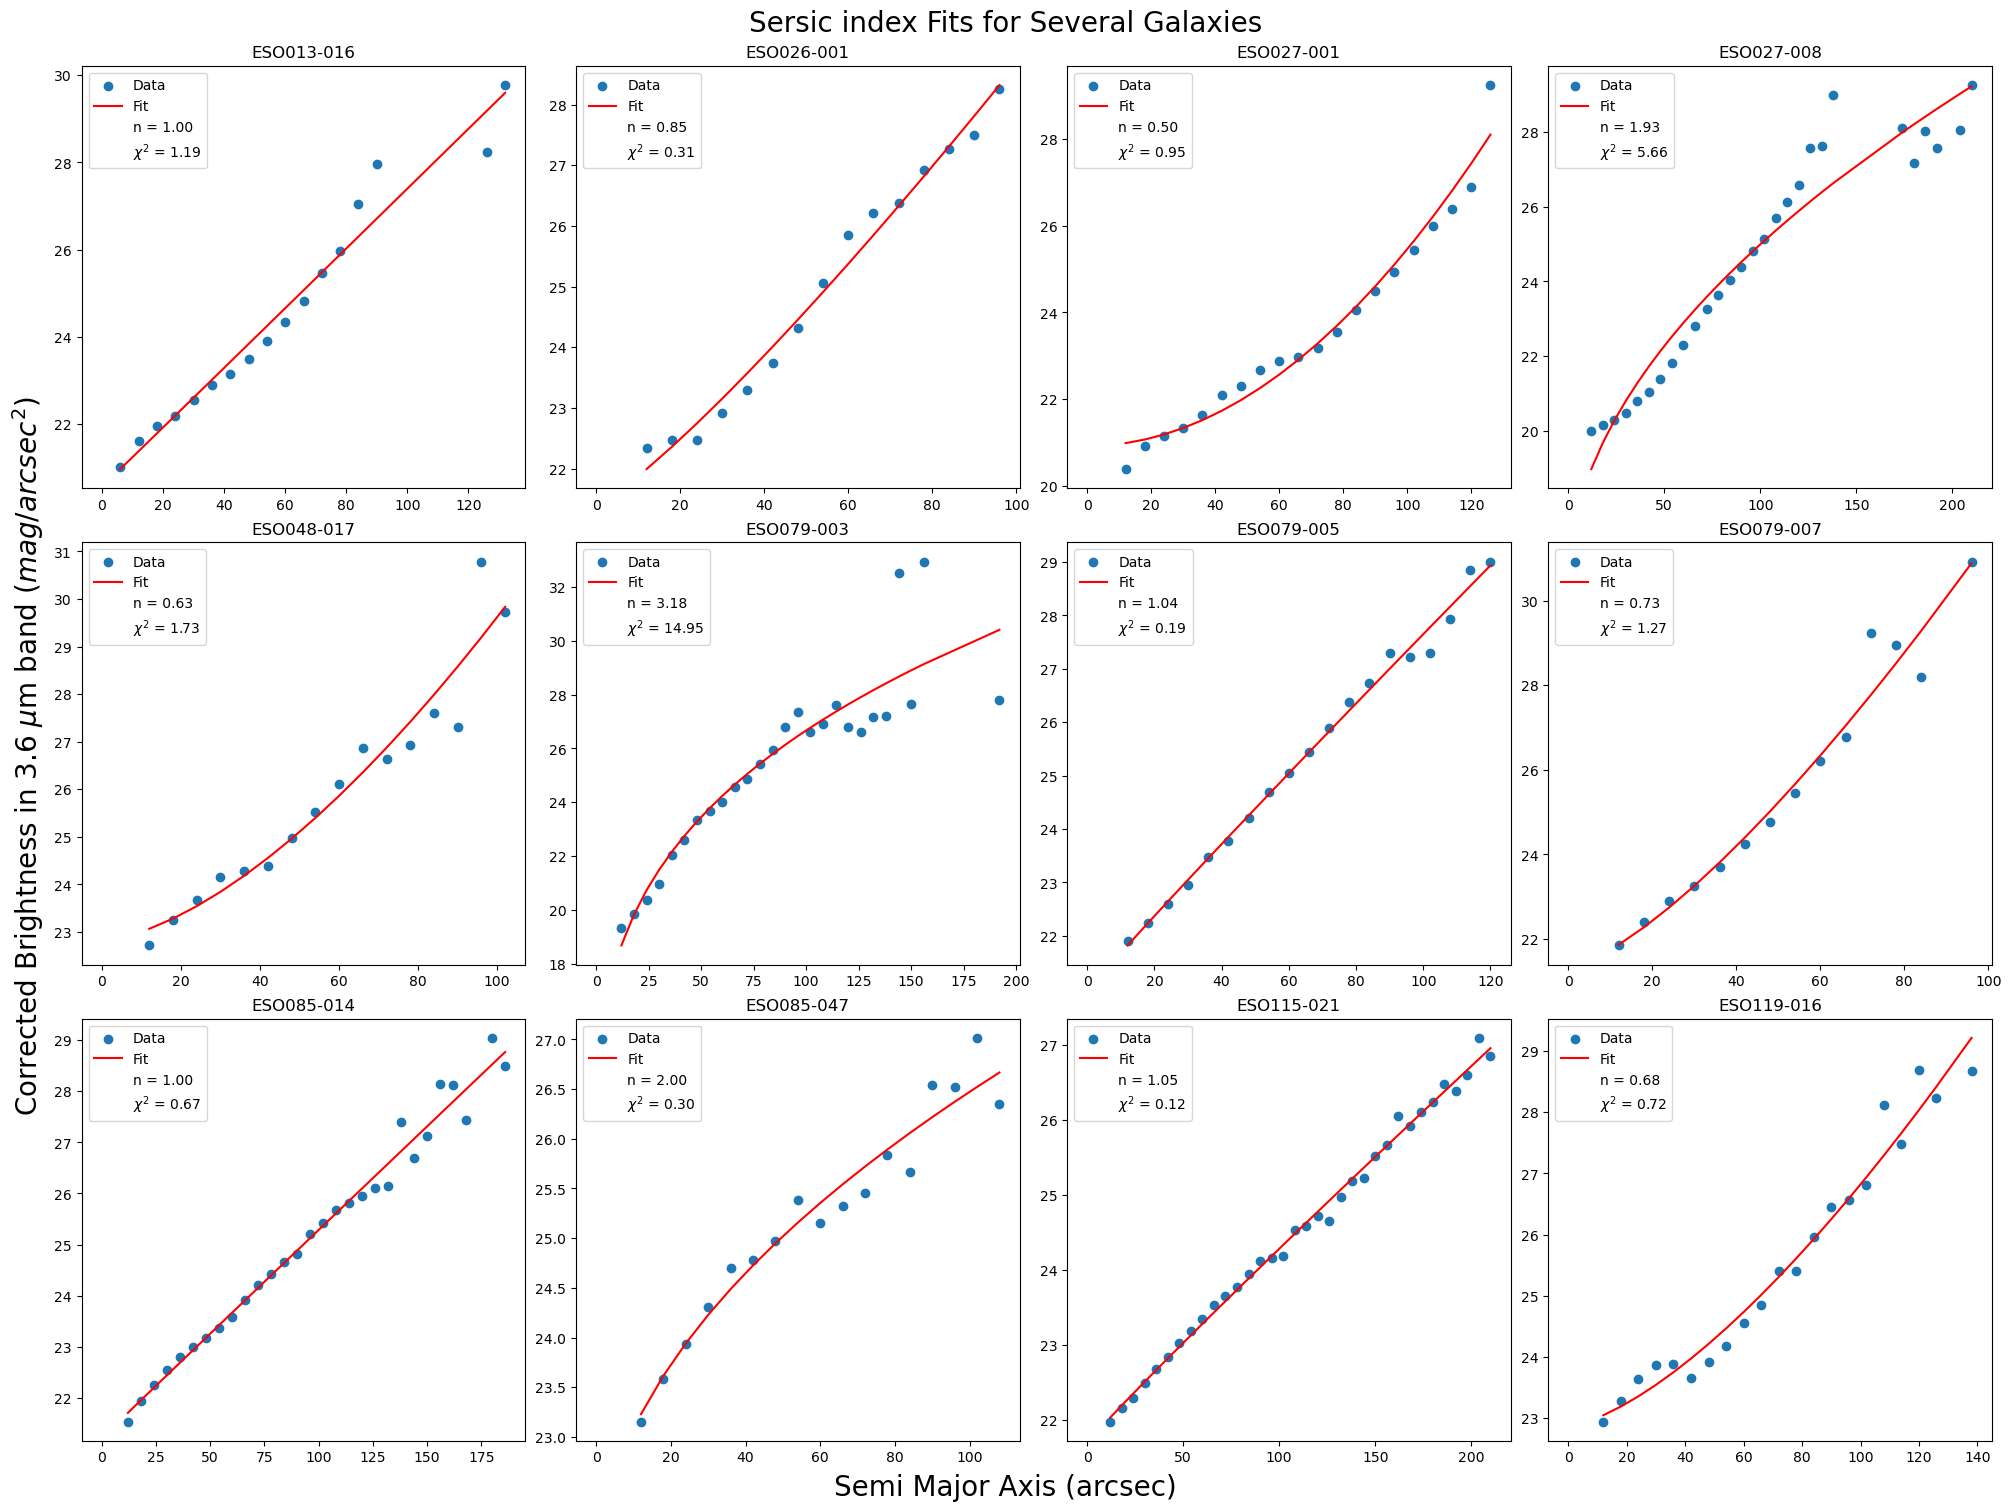

In [47]:
# Setting up the data and performing the fit and then plotting the fits

data = seperate(df_cleaned)
new_data = []
# print(data)

for i in range(len(data)):
    if len(data[i]) > 10:
        new_data.append(data[i])

fig, axs = plt.subplots(3, 4, figsize = (20, 15), constrained_layout = True)
axs = axs.flatten()

lower_bound = [-np.inf, 0, 0.5]
upper_bound = [np.inf, np.inf, 10]

for i in range(len(new_data)):
    galaxy = new_data[i]
    x_data = [point[1] for point in galaxy]
    y_data = [point[2] for point in galaxy]

    x = np.array(x_data, dtype=float)
    y = np.array(y_data, dtype=float)

    # --- DYNAMIC GUESSES ---
    # Estimate mue: Use the median brightness or the brightness near the center
    guess_mue = np.min(y) + 3

    # Estimate re: Use half the max radius as a rough starting point
    guess_re = (np.max(x) - np.min(x)) / 20 

    # Estimate n: Start with 2 (average between Spiral n=1 and Elliptical n=4)
    guess_n = 2 

    start_pars = [guess_mue, guess_re, guess_n]

    popt, pcov = opt.curve_fit(mu_fit, x, y, p0 = start_pars, bounds = (lower_bound, upper_bound))

    # n_fit = popt[2]
    # print(n_fit)

    axs[i].scatter(x, y, label='Data')

    y_fit = mu_fit(x, *popt)
    axs[i].plot(x, y_fit, 'r-', label='Fit')

    #Find chi squared for each plot
    chi_squared_mu = chi_squared(y, y_fit, 3)

    axs[i].set_title(f'{galaxy[i][0]}')
    axs[i].plot(0, 25, label = f'n = {popt[2]:.2f}', linestyle = ' ')
    axs[i].plot(0, 25, label = f'$\chi^2$ = {chi_squared_mu:.2f}', linestyle = ' ')
    axs[i].legend()

fig.supxlabel('Semi Major Axis (arcsec)', fontsize = 20)
fig.supylabel(r'Corrected Brightness in 3.6 $\mu$m band (${{mag}}/{{arcsec^2}}$)', fontsize = 20)
fig.suptitle('Sersic index Fits for Several Galaxies', fontsize = 20)
plt.show()

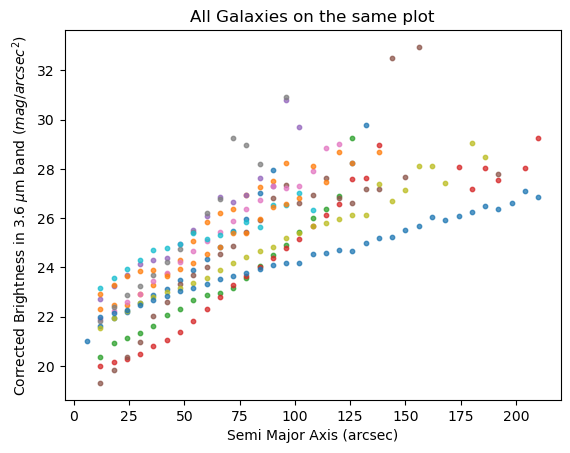

In [49]:
#Plotting the raw data in its own plot with each galaxy having a different color
fig = plt.figure()

for i in range(len(new_data)):
    galaxy = new_data[i]
    x_data = [point[1] for point in galaxy]
    y_data = [point[2] for point in galaxy]

    x = np.array(x_data, dtype=float)
    y = np.array(y_data, dtype=float)

    plt.scatter(x, y, alpha = 0.75, s = 10, label = "Data")


plt.title("All Galaxies on the same plot")
plt.xlabel('Semi Major Axis (arcsec)')
plt.ylabel(r'Corrected Brightness in 3.6 $\mu$m band (${{mag}}/{{arcsec^2}}$)')
plt.show()

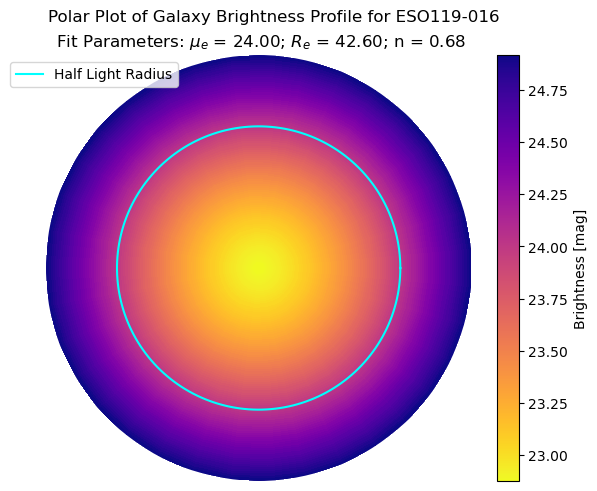

In [37]:
#Plotting the polar representation
r = np.linspace(0, 42.6*1.5, 100)
theta = np.linspace(0, 2*np.pi, 36)

R, THETA = np.meshgrid(r, theta)

fit_params = popt

theta_ring = np.linspace(0, 2*np.pi, 200)
re_val = fit_params[1]

r_ring = np.full_like(theta_ring, re_val)

Z = mu_fit(R, *fit_params)

fig, ax = plt.subplots(subplot_kw = {'projection': 'polar'}, constrained_layout = True)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.axis('off')

c = ax.pcolormesh(THETA, R, Z, shading = 'auto', cmap = 'plasma_r')

ax.plot(theta_ring, r_ring, c = 'cyan', label = "Half Light Radius")

plt.colorbar(c, label = 'Brightness [mag]')
plt.suptitle("Polar Plot of Galaxy Brightness Profile for ESO119-016")
plt.title(f' Fit Parameters: ${{\mu_e}}$ = {fit_params[0]:.2f}; ${{R_e}}$ = {fit_params[1]:.2f}; n = {fit_params[2]:.2f}')
ax.legend(loc='upper left', bbox_to_anchor=(-0.1, 1.0))

plt.show()